# 03 - HistGradientBoosting: capacity, nonlinear structure and distributional errors

This notebook treats `HistGradientBoostingRegressor` as a **diagnostic tool for nonlinear predictive structure**, not merely as a model that may win a leaderboard.

The scientific questions are:

1. **Benchmark:** does HGB raise the predictive frontier relative to the linear family?
2. **Learning dynamics:** how do `learning_rate` and `max_iter` interact?
3. **Tree capacity:** how much leaf capacity is useful before overfitting?
4. **Local smoothness:** how local can terminal leaves become before they fit noise?
5. **Leaf regularization:** does `l2_regularization` improve generalization?
6. **Distributional errors:** does HGB improve decile errors and prediction compression, or do tail problems persist?

This notebook follows the project convention:

```text
Backend:
  runs experiments from YAML configs and writes artifacts under reports/runs/<run_id>/

Notebook:
  reads existing artifacts, builds thesis tables and final figures under reports/notebook_outputs/
```

## Output contract

This notebook writes outputs to:

```text
reports/notebook_outputs/hgb_capacity_and_distribution/
```

Expected final tables:

```text
T1_hgb_benchmark_summary.csv
T2_hgb_top_configs.csv
T3_hgb_lr_iter_tradeoff.csv
T4_hgb_leaf_capacity_tradeoff.csv
T5_hgb_min_leaf_tradeoff.csv
T6_hgb_l2_tradeoff.csv
T7_hgb_distribution_error_summary.csv
T8_hgb_selected_config_manifest.csv
```

Expected final figures:

```text
F1_hgb_vs_linear_benchmark.png
F2_hgb_lr_iter_cv_r2.png
F3_hgb_leaf_capacity_cv_gap.png
F4_hgb_min_leaf_cv_gap.png
F5_hgb_l2_regularization_cv_gap.png
F6_hgb_decile_errors.png
F7_hgb_prediction_compression.png
F8_hgb_observed_vs_predicted.png
```

## 00. Setup and run discovery

In [22]:
from pathlib import Path
import json
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Robust root resolution: works from repo root and from notebooks/.
ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/matias/repos/income-modeling-eph"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "reports" / "runs").exists()),
    Path("/home/matias/repos/income-modeling-eph"),
)

RUNS_DIR = ROOT / "reports" / "runs"
DATASET_PATH = ROOT / "data" / "processed" / "modeling_dataset.parquet"

OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "hgb_capacity_and_distribution"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


def latest_run(pattern: str) -> Path | None:
    candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
    return candidates[-1] if candidates else None


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"MISSING CSV: {path}")
        return pd.DataFrame()
    return pd.read_csv(path)


def read_parquet_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"MISSING PARQUET: {path}")
        return pd.DataFrame()
    return pd.read_parquet(path)


def read_json_if_exists(path: Path):
    if not path.exists():
        print(f"MISSING JSON: {path}")
        return None
    return json.loads(path.read_text())


def read_yaml_if_exists(path: Path):
    if not path.exists():
        print(f"MISSING YAML: {path}")
        return None
    return yaml.safe_load(path.read_text())


def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


# Experiment patterns used by the backend.
RUN_PATTERNS = {
    "baseline": "baseline_income_prediction_v1_*",
    "hgb_sweep": "hgb_sweep_v1_*",
    "hgb_lr_iter": "hgb_lr_iter_sweep_v1_*",
    "hgb_leaf_capacity": "hgb_leaf_capacity_sweep_v1_*",
    "hgb_min_leaf": "hgb_min_leaf_sweep_v1_*",
    "hgb_l2": "hgb_l2_sweep_v1_*",
    # Optional quick benchmark used earlier in the thesis workflow.
    "hgb_quick_benchmark": "hgb_quick_benchmark_v1_*",
}

run_dirs = {name: latest_run(pattern) for name, pattern in RUN_PATTERNS.items()}

print("Discovered runs:")
for name, path in run_dirs.items():
    print(f"{name:24s}", path)

ROOT: /home/matias/repos/income-modeling-eph
RUNS_DIR: /home/matias/repos/income-modeling-eph/reports/runs
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/hgb_capacity_and_distribution
Discovered runs:
baseline                 /home/matias/repos/income-modeling-eph/reports/runs/baseline_income_prediction_v1_20260608T100650Z
hgb_sweep                /home/matias/repos/income-modeling-eph/reports/runs/hgb_sweep_v1_20260517T092712Z
hgb_lr_iter              /home/matias/repos/income-modeling-eph/reports/runs/hgb_lr_iter_sweep_v1_20260609T063641Z
hgb_leaf_capacity        /home/matias/repos/income-modeling-eph/reports/runs/hgb_leaf_capacity_sweep_v1_20260609T063012Z
hgb_min_leaf             /home/matias/repos/income-modeling-eph/reports/runs/hgb_min_leaf_sweep_v1_20260609T063344Z
hgb_l2                   /home/matias/repos/income-modeling-eph/reports/runs/hgb_l2_sweep_v1_20260609T064712Z
hgb_quick_benchmark      /home/matias/repos/income-modeling-eph/reports/runs/

## 01. Artifact loaders

In [23]:
def load_run_bundle(name: str, run_dir: Path | None) -> dict:
    if run_dir is None:
        return {
            "name": name,
            "run_dir": None,
            "available": False,
            "model_comparison": pd.DataFrame(),
            "metrics_long": pd.DataFrame(),
            "cv_results": pd.DataFrame(),
            "hgb_cv_results": pd.DataFrame(),
            "hgb_top_configs": pd.DataFrame(),
            "hgb_overfit_gap": pd.DataFrame(),
            "residual_summary": pd.DataFrame(),
            "error_by_decile": pd.DataFrame(),
            "prediction_distribution": pd.DataFrame(),
            "compression_summary": pd.DataFrame(),
            "predictions": pd.DataFrame(),
            "run_manifest": None,
            "experiment_card": None,
            "config_used": None,
        }

    metrics_dir = run_dir / "metrics"
    diagnostics_dir = run_dir / "diagnostics"
    predictions_dir = run_dir / "predictions"
    cv_dir = run_dir / "cv_results"

    cv_frames = []
    for path in sorted(cv_dir.glob("*.csv")):
        tmp = read_csv_if_exists(path)
        if tmp.empty:
            continue
        if "model" not in tmp.columns:
            tmp["model"] = path.stem
        tmp["cv_file"] = path.name
        cv_frames.append(tmp)

    cv_results = pd.concat(cv_frames, ignore_index=True) if cv_frames else pd.DataFrame()

    # HGB-specific cv file if present.
    hgb_cv = pd.DataFrame()
    for candidate in [
        cv_dir / "HistGradientBoostingRegressor.csv",
        cv_dir / "HGB.csv",
        cv_dir / "hist_gradient_boosting.csv",
    ]:
        if candidate.exists():
            hgb_cv = read_csv_if_exists(candidate)
            break

    pred_frames = []
    for split in ["test", "validation"]:
        path = predictions_dir / f"{split}_predictions.parquet"
        tmp = read_parquet_if_exists(path)
        if tmp.empty:
            continue
        tmp["split"] = split
        pred_frames.append(tmp)

    predictions = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()

    if not predictions.empty:
        if "residual" not in predictions.columns:
            predictions["residual"] = predictions["y_true"] - predictions["y_pred"]
        if "abs_error" not in predictions.columns:
            predictions["abs_error"] = predictions["residual"].abs()
        if "squared_error" not in predictions.columns:
            predictions["squared_error"] = predictions["residual"] ** 2

    bundle = {
        "name": name,
        "run_dir": run_dir,
        "available": True,
        "model_comparison": read_csv_if_exists(metrics_dir / "model_comparison.csv"),
        "metrics_long": read_csv_if_exists(metrics_dir / "metrics_long.csv"),
        "cv_results": cv_results,
        "hgb_cv_results": hgb_cv,
        "hgb_top_configs": read_csv_if_exists(diagnostics_dir / "hgb_top_configs.csv"),
        "hgb_overfit_gap": read_csv_if_exists(diagnostics_dir / "hgb_overfit_gap_by_config.csv"),
        "hgb_cv_summary": read_csv_if_exists(diagnostics_dir / "hgb_cv_results_summary.csv"),
        "hgb_sweep_summary": read_csv_if_exists(diagnostics_dir / "hgb_sweep_cv_results_summary.csv"),
        "residual_summary": read_csv_if_exists(diagnostics_dir / "residual_summary.csv"),
        "error_by_decile": read_csv_if_exists(diagnostics_dir / "error_by_income_decile.csv"),
        "prediction_distribution": read_csv_if_exists(diagnostics_dir / "prediction_distribution_summary.csv"),
        "compression_summary": read_csv_if_exists(diagnostics_dir / "distribution_compression_summary.csv"),
        "predictions": predictions,
        "run_manifest": read_json_if_exists(run_dir / "run_manifest.json"),
        "experiment_card": read_json_if_exists(run_dir / "experiment_card.json"),
        "config_used": read_yaml_if_exists(run_dir / "config_used.yaml"),
    }

    for key, value in list(bundle.items()):
        if isinstance(value, pd.DataFrame) and not value.empty:
            value.insert(0, "experiment", name)
            value.insert(1, "run_dir", str(run_dir))

    return bundle


bundles = {name: load_run_bundle(name, path) for name, path in run_dirs.items()}

print("Loaded bundles:")
for name, b in bundles.items():
    print(f"{name:24s}", "available" if b["available"] else "missing")

MISSING CSV: /home/matias/repos/income-modeling-eph/reports/runs/baseline_income_prediction_v1_20260608T100650Z/diagnostics/hgb_sweep_cv_results_summary.csv
MISSING PARQUET: /home/matias/repos/income-modeling-eph/reports/runs/hgb_sweep_v1_20260517T092712Z/predictions/test_predictions.parquet
MISSING PARQUET: /home/matias/repos/income-modeling-eph/reports/runs/hgb_sweep_v1_20260517T092712Z/predictions/validation_predictions.parquet
MISSING CSV: /home/matias/repos/income-modeling-eph/reports/runs/hgb_sweep_v1_20260517T092712Z/metrics/model_comparison.csv
MISSING CSV: /home/matias/repos/income-modeling-eph/reports/runs/hgb_sweep_v1_20260517T092712Z/metrics/metrics_long.csv
MISSING CSV: /home/matias/repos/income-modeling-eph/reports/runs/hgb_sweep_v1_20260517T092712Z/diagnostics/hgb_top_configs.csv
MISSING CSV: /home/matias/repos/income-modeling-eph/reports/runs/hgb_sweep_v1_20260517T092712Z/diagnostics/hgb_overfit_gap_by_config.csv
MISSING CSV: /home/matias/repos/income-modeling-eph/repor

## 02. Experiment inventory

In [24]:
inventory_rows = []

for name, b in bundles.items():
    run_dir = b["run_dir"]
    manifest = b["run_manifest"] or {}
    card = b["experiment_card"] or {}
    cfg = b["config_used"] or {}

    inventory_rows.append({
        "experiment": name,
        "available": b["available"],
        "run_dir": str(run_dir) if run_dir is not None else None,
        "run_id": manifest.get("run_id") or card.get("run_id"),
        "rows_used": manifest.get("rows_used") or card.get("rows_used"),
        "feature_count": manifest.get("feature_count") or card.get("feature_count"),
        "models": ", ".join(manifest.get("models", []) or card.get("models", [])),
        "mode": manifest.get("mode") or card.get("mode") or (cfg.get("runtime", {}) if isinstance(cfg, dict) else {}).get("mode"),
        "cv_rows": len(b["cv_results"]),
        "hgb_cv_rows": len(b["hgb_cv_results"]),
        "prediction_rows": len(b["predictions"]),
    })

experiment_inventory = pd.DataFrame(inventory_rows)
experiment_inventory.to_csv(TABLE_DIR / "experiment_inventory.csv", index=False)
experiment_inventory

,experiment,available,run_dir,run_id,rows_used,feature_count,models,mode,cv_rows,hgb_cv_rows,prediction_rows
0,baseline,True,/home/matias/repos/income-modeling-eph/reports...,baseline_income_prediction_v1_20260608T100650Z,356791.0,37.0,"LinearRegression, Ridge, Lasso, HistGradientBo...",full,47,24,535185
1,hgb_sweep,True,/home/matias/repos/income-modeling-eph/reports...,NaN,NaN,NaN,,sweep,0,0,0
2,hgb_lr_iter,True,/home/matias/repos/income-modeling-eph/reports...,hgb_lr_iter_sweep_v1_20260609T063641Z,100000.0,37.0,HistGradientBoostingRegressor,sweep,20,20,30000
3,hgb_leaf_capacity,True,/home/matias/repos/income-modeling-eph/reports...,hgb_leaf_capacity_sweep_v1_20260609T063012Z,100000.0,37.0,HistGradientBoostingRegressor,sweep,8,8,30000
4,hgb_min_leaf,True,/home/matias/repos/income-modeling-eph/reports...,hgb_min_leaf_sweep_v1_20260609T063344Z,100000.0,37.0,HistGradientBoostingRegressor,sweep,8,8,30000
5,hgb_l2,True,/home/matias/repos/income-modeling-eph/reports...,hgb_l2_sweep_v1_20260609T064712Z,100000.0,37.0,HistGradientBoostingRegressor,sweep,8,8,30000
6,hgb_quick_benchmark,True,/home/matias/repos/income-modeling-eph/reports...,hgb_quick_benchmark_v1_20260609T061007Z,100000.0,35.0,HistGradientBoostingRegressor,sweep,1,1,30000


## 03. HGB benchmark vs linear reference

In [25]:
# Build benchmark table from baseline if available, otherwise use quick benchmark + any available linear reference.
baseline_bundle = bundles.get("baseline")
quick_bundle = bundles.get("hgb_quick_benchmark")

benchmark_frames = []

if baseline_bundle and not baseline_bundle["model_comparison"].empty:
    baseline_mc = baseline_bundle["model_comparison"].copy()
    benchmark_frames.append(baseline_mc)

if quick_bundle and not quick_bundle["model_comparison"].empty:
    quick_mc = quick_bundle["model_comparison"].copy()
    benchmark_frames.append(quick_mc)

benchmark_summary = pd.concat(benchmark_frames, ignore_index=True) if benchmark_frames else pd.DataFrame()

# Keep a compact benchmark summary.
benchmark_cols = [
    "experiment",
    "model",
    "cv_r2_mean",
    "cv_r2_std",
    "test_r2",
    "validation_r2",
    "test_mae",
    "validation_mae",
    "fit_time_seconds",
    "feature_count",
]
benchmark_cols = [c for c in benchmark_cols if c in benchmark_summary.columns]

T1_hgb_benchmark_summary = (
    benchmark_summary[benchmark_cols]
    .sort_values([c for c in ["experiment", "validation_r2", "cv_r2_mean"] if c in benchmark_cols], ascending=[True, False, False][:len([c for c in ["experiment", "validation_r2", "cv_r2_mean"] if c in benchmark_cols])])
    .reset_index(drop=True)
    if not benchmark_summary.empty else pd.DataFrame(columns=benchmark_cols)
)

T1_hgb_benchmark_summary.to_csv(TABLE_DIR / "T1_hgb_benchmark_summary.csv", index=False)
T1_hgb_benchmark_summary.round(6)

,experiment,model,cv_r2_mean,cv_r2_std,test_r2,validation_r2,test_mae,validation_mae,fit_time_seconds,feature_count
0,baseline,HistGradientBoostingRegressor,0.562229,0.017551,0.602092,0.601854,0.174538,0.175124,2359.041964,37
1,baseline,MLPRegressor,0.453415,0.061289,0.557501,0.556714,0.186727,0.187266,40752.622302,37
2,baseline,LinearRegression,0.407654,0.018238,0.419484,0.417921,0.213958,0.214159,27.651960,37
3,baseline,Ridge,0.407653,0.018250,0.419484,0.417908,0.213952,0.214157,55.399482,37
4,baseline,Lasso,0.394226,0.019220,0.403379,0.399430,0.216004,0.216846,68.737110,37
5,hgb_quick_benchmark,HistGradientBoostingRegressor,0.544790,0.013599,0.579654,0.574243,0.181592,0.180559,20.897333,35


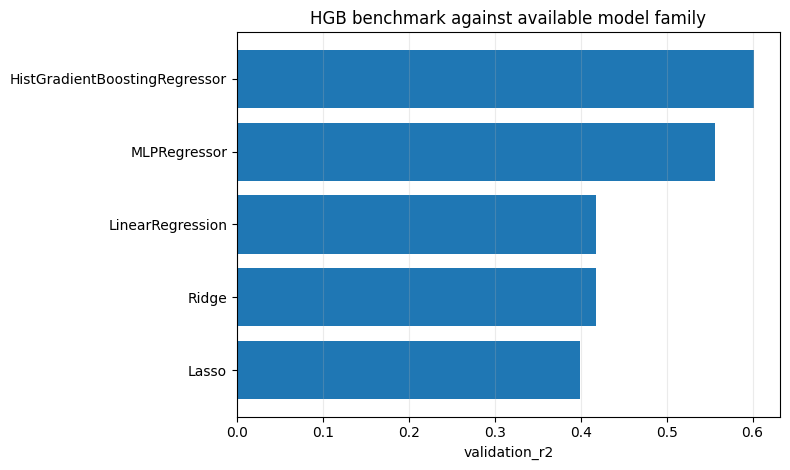

In [26]:
# Figure F1: benchmark by model.
if not T1_hgb_benchmark_summary.empty:
    plot_df = T1_hgb_benchmark_summary.copy()

    metric_col = "validation_r2" if "validation_r2" in plot_df.columns else "cv_r2_mean"
    plot_df = plot_df.dropna(subset=[metric_col])

    # Prefer baseline if it contains multiple models. Otherwise use all rows.
    if "baseline" in set(plot_df["experiment"]) and plot_df.query("experiment == 'baseline'")["model"].nunique() > 1:
        plot_df = plot_df.query("experiment == 'baseline'").copy()

    plot_df = plot_df.sort_values(metric_col, ascending=True)

    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.barh(plot_df["model"], plot_df[metric_col])
    ax.set_xlabel(metric_col)
    ax.set_title("HGB benchmark against available model family")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F1_hgb_vs_linear_benchmark.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No benchmark summary available.")

## 04. HGB CV normalization helpers

In [27]:
def standardize_hgb_cv(df: pd.DataFrame, experiment: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    out = df.copy()
    out["experiment"] = experiment

    # Core scores.
    if "mean_test_score" in out.columns:
        out["cv_r2"] = pd.to_numeric(out["mean_test_score"], errors="coerce")
    elif "cv_r2_mean" in out.columns:
        out["cv_r2"] = pd.to_numeric(out["cv_r2_mean"], errors="coerce")
    elif "mean_cv_score" in out.columns:
        out["cv_r2"] = pd.to_numeric(out["mean_cv_score"], errors="coerce")

    if "mean_train_score" in out.columns:
        out["train_r2"] = pd.to_numeric(out["mean_train_score"], errors="coerce")
    elif "train_r2_mean" in out.columns:
        out["train_r2"] = pd.to_numeric(out["train_r2_mean"], errors="coerce")
    elif "mean_train_r2" in out.columns:
        out["train_r2"] = pd.to_numeric(out["mean_train_r2"], errors="coerce")

    if "std_test_score" in out.columns:
        out["cv_r2_std"] = pd.to_numeric(out["std_test_score"], errors="coerce")
    elif "cv_r2_std" in out.columns:
        out["cv_r2_std"] = pd.to_numeric(out["cv_r2_std"], errors="coerce")
    else:
        out["cv_r2_std"] = np.nan

    if "train_r2" in out.columns and "cv_r2" in out.columns:
        out["overfit_gap"] = out["train_r2"] - out["cv_r2"]

    # Hyperparameters.
    param_map = {
        "learning_rate": ["param_reg__learning_rate", "learning_rate", "reg__learning_rate"],
        "max_iter": ["param_reg__max_iter", "max_iter", "reg__max_iter"],
        "max_leaf_nodes": ["param_reg__max_leaf_nodes", "max_leaf_nodes", "reg__max_leaf_nodes"],
        "min_samples_leaf": ["param_reg__min_samples_leaf", "min_samples_leaf", "reg__min_samples_leaf"],
        "l2_regularization": ["param_reg__l2_regularization", "l2_regularization", "reg__l2_regularization"],
    }

    for canonical, candidates in param_map.items():
        source = first_existing(out.columns, candidates)
        if source is not None:
            out[canonical] = pd.to_numeric(out[source], errors="coerce")

    if "rank_test_score" in out.columns:
        out["rank_test_score"] = pd.to_numeric(out["rank_test_score"], errors="coerce")

    return out


hgb_cv_frames = []
for name, b in bundles.items():
    if not b["hgb_cv_results"].empty:
        hgb_cv_frames.append(standardize_hgb_cv(b["hgb_cv_results"], name))
    elif not b["cv_results"].empty:
        # Fallback: select HGB rows from generic cv_results.
        tmp = b["cv_results"].copy()
        if "model" in tmp.columns:
            tmp = tmp[tmp["model"].astype(str).str.contains("HistGradientBoosting|HGB", case=False, regex=True)]
        if not tmp.empty:
            hgb_cv_frames.append(standardize_hgb_cv(tmp, name))

hgb_cv_all = pd.concat(hgb_cv_frames, ignore_index=True) if hgb_cv_frames else pd.DataFrame()

print("hgb_cv_all:", hgb_cv_all.shape)
print(hgb_cv_all.columns.tolist())
hgb_cv_all.head()

hgb_cv_all: (69, 37)
['experiment', 'run_dir', 'run_id', 'model', 'mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_reg__l2_regularization', 'param_reg__learning_rate', 'param_reg__max_iter', 'param_reg__max_leaf_nodes', 'param_reg__min_samples_leaf', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'cv_r2', 'cv_r2_std', 'learning_rate', 'max_iter', 'max_leaf_nodes', 'min_samples_leaf', 'l2_regularization', 'param_reg__early_stopping', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'mean_train_score', 'std_train_score', 'train_r2', 'overfit_gap', 'param_reg__loss', 'param_reg__random_state']


,experiment,run_dir,run_id,model,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_reg__l2_regularization,param_reg__learning_rate,...,param_reg__early_stopping,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score,train_r2,overfit_gap,param_reg__loss,param_reg__random_state
0,baseline,/home/matias/repos/income-modeling-eph/reports...,baseline_income_prediction_v1_20260608T100650Z,HistGradientBoostingRegressor,17.803723,1.310364,1.412124,0.096915,0.0,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,baseline,/home/matias/repos/income-modeling-eph/reports...,baseline_income_prediction_v1_20260608T100650Z,HistGradientBoostingRegressor,14.775572,0.545543,1.393863,0.140993,0.0,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,baseline,/home/matias/repos/income-modeling-eph/reports...,baseline_income_prediction_v1_20260608T100650Z,HistGradientBoostingRegressor,15.623771,1.959853,0.984625,0.095384,0.0,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,baseline,/home/matias/repos/income-modeling-eph/reports...,baseline_income_prediction_v1_20260608T100650Z,HistGradientBoostingRegressor,19.846216,1.598780,1.585137,0.262524,0.0,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,baseline,/home/matias/repos/income-modeling-eph/reports...,baseline_income_prediction_v1_20260608T100650Z,HistGradientBoostingRegressor,18.627152,1.697703,1.753972,0.113619,0.0,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 05. Combined top-config analysis

In [28]:
# T2: top configs across all HGB experiments with CV results.
if not hgb_cv_all.empty:
    T2_cols = [
        "experiment",
        "model",
        "cv_r2",
        "cv_r2_std",
        "train_r2",
        "overfit_gap",
        "mean_fit_time",
        "learning_rate",
        "max_iter",
        "max_leaf_nodes",
        "min_samples_leaf",
        "l2_regularization",
        "rank_test_score",
    ]
    T2_cols = [c for c in T2_cols if c in hgb_cv_all.columns]

    T2_hgb_top_configs = (
        hgb_cv_all[T2_cols]
        .dropna(subset=["cv_r2"])
        .sort_values("cv_r2", ascending=False)
        .head(30)
        .reset_index(drop=True)
    )
else:
    T2_hgb_top_configs = pd.DataFrame()

T2_hgb_top_configs.to_csv(TABLE_DIR / "T2_hgb_top_configs.csv", index=False)
T2_hgb_top_configs.round(6)

,experiment,model,cv_r2,cv_r2_std,train_r2,overfit_gap,mean_fit_time,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,rank_test_score
0,baseline,HistGradientBoostingRegressor,0.562229,0.017551,NaN,NaN,52.173794,0.05,200,400,15,0.000,1
1,baseline,HistGradientBoostingRegressor,0.561968,0.017539,NaN,NaN,62.516766,0.05,200,400,30,0.000,2
2,baseline,HistGradientBoostingRegressor,0.561373,0.016441,NaN,NaN,62.827913,0.05,200,200,15,0.000,3
3,baseline,HistGradientBoostingRegressor,0.560714,0.017045,NaN,NaN,43.581028,0.05,200,200,30,0.000,4
4,baseline,HistGradientBoostingRegressor,0.559792,0.014022,NaN,NaN,46.226535,0.05,100,400,30,0.000,5
5,baseline,HistGradientBoostingRegressor,0.559679,0.014497,NaN,NaN,35.226082,0.05,100,400,15,0.000,6
6,baseline,HistGradientBoostingRegressor,0.559548,0.018214,NaN,NaN,26.067229,0.10,200,200,15,0.000,7
7,baseline,HistGradientBoostingRegressor,0.559447,0.018577,NaN,NaN,28.006224,0.10,200,200,30,0.000,8
8,baseline,HistGradientBoostingRegressor,0.559363,0.017607,NaN,NaN,25.175457,0.10,100,400,30,0.000,9
9,baseline,HistGradientBoostingRegressor,0.559053,0.016990,NaN,NaN,13.898770,0.10,100,200,15,0.000,10


## 06. Learning rate and max-iteration sweep

In [29]:
lr_iter = hgb_cv_all.query("experiment == 'hgb_lr_iter'").copy()

T3_cols = [
    "experiment",
    "learning_rate",
    "max_iter",
    "cv_r2",
    "cv_r2_std",
    "train_r2",
    "overfit_gap",
    "mean_fit_time",
]
T3_cols = [c for c in T3_cols if c in lr_iter.columns]

T3_hgb_lr_iter_tradeoff = (
    lr_iter[T3_cols]
    .sort_values([c for c in ["learning_rate", "max_iter"] if c in T3_cols])
    .reset_index(drop=True)
    if not lr_iter.empty else pd.DataFrame(columns=T3_cols)
)

T3_hgb_lr_iter_tradeoff.to_csv(TABLE_DIR / "T3_hgb_lr_iter_tradeoff.csv", index=False)
T3_hgb_lr_iter_tradeoff.round(6)

,experiment,learning_rate,max_iter,cv_r2,cv_r2_std,train_r2,overfit_gap,mean_fit_time
0,hgb_lr_iter,0.020,100,0.492470,0.009363,0.508306,0.015837,3.152559
1,hgb_lr_iter,0.020,200,0.531179,0.009327,0.557565,0.026385,5.377458
2,hgb_lr_iter,0.020,400,0.543375,0.012892,0.586916,0.043541,9.788839
3,hgb_lr_iter,0.020,600,0.546222,0.013356,0.601287,0.055065,13.336259
4,hgb_lr_iter,0.030,100,0.520008,0.008682,0.540969,0.020961,3.194139
5,hgb_lr_iter,0.030,200,0.540422,0.011525,0.576207,0.035785,5.496288
6,hgb_lr_iter,0.030,400,0.546233,0.013185,0.601525,0.055293,9.515272
7,hgb_lr_iter,0.030,600,0.547219,0.013558,0.617381,0.070162,14.329030
8,hgb_lr_iter,0.050,100,0.537561,0.010442,0.568683,0.031122,3.034049
9,hgb_lr_iter,0.050,200,0.545198,0.013008,0.595306,0.050108,5.487845


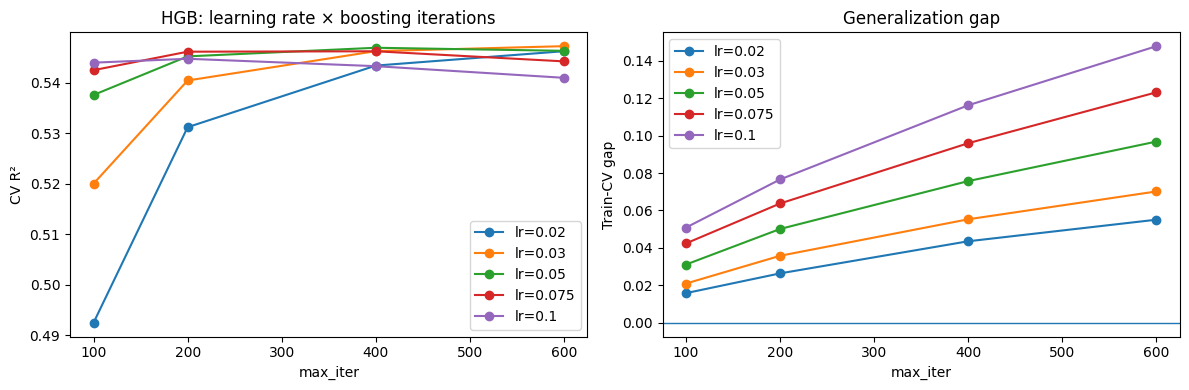

In [30]:
if not lr_iter.empty and {"learning_rate", "max_iter", "cv_r2"}.issubset(lr_iter.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for lr, g in lr_iter.sort_values("max_iter").groupby("learning_rate"):
        label = f"lr={lr:g}"
        axes[0].plot(g["max_iter"], g["cv_r2"], marker="o", label=label)
        if "overfit_gap" in g.columns:
            axes[1].plot(g["max_iter"], g["overfit_gap"], marker="o", label=label)

    axes[0].set_xlabel("max_iter")
    axes[0].set_ylabel("CV R²")
    axes[0].set_title("HGB: learning rate × boosting iterations")
    axes[0].legend()

    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("max_iter")
    axes[1].set_ylabel("Train-CV gap")
    axes[1].set_title("Generalization gap")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F2_hgb_lr_iter_cv_r2.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Learning-rate / max-iter sweep data not available.")

## 07. Leaf-capacity sweep

In [31]:
leaf_capacity = hgb_cv_all.query("experiment == 'hgb_leaf_capacity'").copy()

T4_cols = [
    "experiment",
    "max_leaf_nodes",
    "cv_r2",
    "cv_r2_std",
    "train_r2",
    "overfit_gap",
    "mean_fit_time",
    "learning_rate",
    "max_iter",
    "min_samples_leaf",
    "l2_regularization",
]
T4_cols = [c for c in T4_cols if c in leaf_capacity.columns]

T4_hgb_leaf_capacity_tradeoff = (
    leaf_capacity[T4_cols]
    .sort_values("max_leaf_nodes")
    .reset_index(drop=True)
    if not leaf_capacity.empty and "max_leaf_nodes" in leaf_capacity.columns else pd.DataFrame(columns=T4_cols)
)

T4_hgb_leaf_capacity_tradeoff.to_csv(TABLE_DIR / "T4_hgb_leaf_capacity_tradeoff.csv", index=False)
T4_hgb_leaf_capacity_tradeoff.round(6)

,experiment,max_leaf_nodes,cv_r2,cv_r2_std,train_r2,overfit_gap,mean_fit_time,learning_rate,max_iter,min_samples_leaf,l2_regularization
0,hgb_leaf_capacity,7,0.522245,0.013063,0.542766,0.020521,3.271430,0.05,200,100,0.0
1,hgb_leaf_capacity,15,0.538339,0.012546,0.569203,0.030864,3.592387,0.05,200,100,0.0
2,hgb_leaf_capacity,23,0.542918,0.013168,0.584038,0.041120,4.538780,0.05,200,100,0.0
3,hgb_leaf_capacity,31,0.545198,0.013008,0.595306,0.050108,5.077661,0.05,200,100,0.0
4,hgb_leaf_capacity,47,0.546402,0.012547,0.613129,0.066727,6.294204,0.05,200,100,0.0
5,hgb_leaf_capacity,63,0.547758,0.012804,0.628227,0.080468,6.635493,0.05,200,100,0.0
6,hgb_leaf_capacity,95,0.548996,0.011108,0.652949,0.103952,8.893732,0.05,200,100,0.0
7,hgb_leaf_capacity,127,0.548410,0.011744,0.673549,0.125140,10.218049,0.05,200,100,0.0


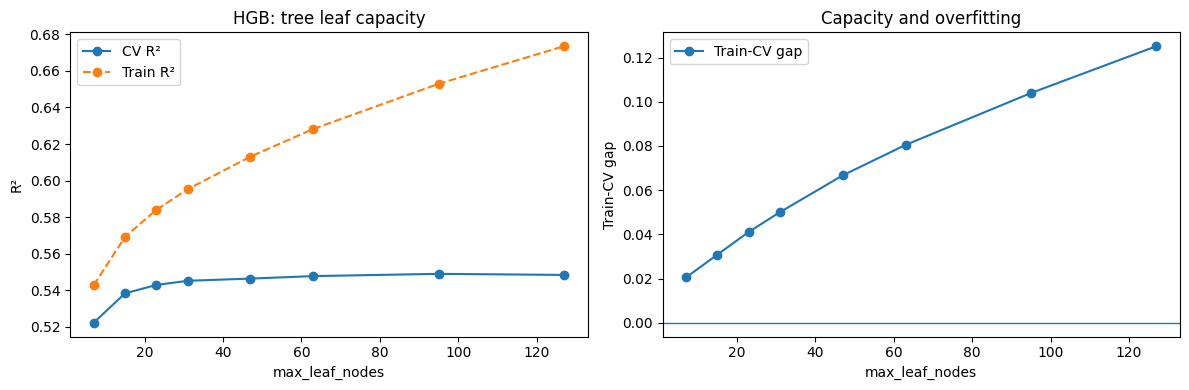

In [32]:
if not leaf_capacity.empty and {"max_leaf_nodes", "cv_r2"}.issubset(leaf_capacity.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    g = leaf_capacity.sort_values("max_leaf_nodes")

    axes[0].plot(g["max_leaf_nodes"], g["cv_r2"], marker="o", label="CV R²")
    if "train_r2" in g.columns:
        axes[0].plot(g["max_leaf_nodes"], g["train_r2"], marker="o", linestyle="--", label="Train R²")
    axes[0].set_xlabel("max_leaf_nodes")
    axes[0].set_ylabel("R²")
    axes[0].set_title("HGB: tree leaf capacity")
    axes[0].legend()

    if "overfit_gap" in g.columns:
        axes[1].plot(g["max_leaf_nodes"], g["overfit_gap"], marker="o", label="Train-CV gap")
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("max_leaf_nodes")
    axes[1].set_ylabel("Train-CV gap")
    axes[1].set_title("Capacity and overfitting")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F3_hgb_leaf_capacity_cv_gap.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Leaf-capacity sweep data not available.")

## 08. Min-samples-leaf sweep

In [33]:
min_leaf = hgb_cv_all.query("experiment == 'hgb_min_leaf'").copy()

T5_cols = [
    "experiment",
    "min_samples_leaf",
    "cv_r2",
    "cv_r2_std",
    "train_r2",
    "overfit_gap",
    "mean_fit_time",
    "learning_rate",
    "max_iter",
    "max_leaf_nodes",
    "l2_regularization",
]
T5_cols = [c for c in T5_cols if c in min_leaf.columns]

T5_hgb_min_leaf_tradeoff = (
    min_leaf[T5_cols]
    .sort_values("min_samples_leaf")
    .reset_index(drop=True)
    if not min_leaf.empty and "min_samples_leaf" in min_leaf.columns else pd.DataFrame(columns=T5_cols)
)

T5_hgb_min_leaf_tradeoff.to_csv(TABLE_DIR / "T5_hgb_min_leaf_tradeoff.csv", index=False)
T5_hgb_min_leaf_tradeoff.round(6)

,experiment,min_samples_leaf,cv_r2,cv_r2_std,train_r2,overfit_gap,mean_fit_time,learning_rate,max_iter,max_leaf_nodes,l2_regularization
0,hgb_min_leaf,20,0.546546,0.012815,0.600851,0.054305,4.730165,0.05,200,31,0.0
1,hgb_min_leaf,30,0.546811,0.012973,0.600133,0.053322,4.950497,0.05,200,31,0.0
2,hgb_min_leaf,50,0.546478,0.012286,0.598682,0.052204,5.297702,0.05,200,31,0.0
3,hgb_min_leaf,75,0.545268,0.013271,0.596171,0.050902,4.949190,0.05,200,31,0.0
4,hgb_min_leaf,100,0.545198,0.013008,0.595306,0.050108,4.852530,0.05,200,31,0.0
5,hgb_min_leaf,150,0.544625,0.012711,0.593257,0.048632,5.092890,0.05,200,31,0.0
6,hgb_min_leaf,200,0.544513,0.012636,0.591690,0.047178,4.740620,0.05,200,31,0.0
7,hgb_min_leaf,300,0.543437,0.012960,0.589005,0.045568,5.017199,0.05,200,31,0.0


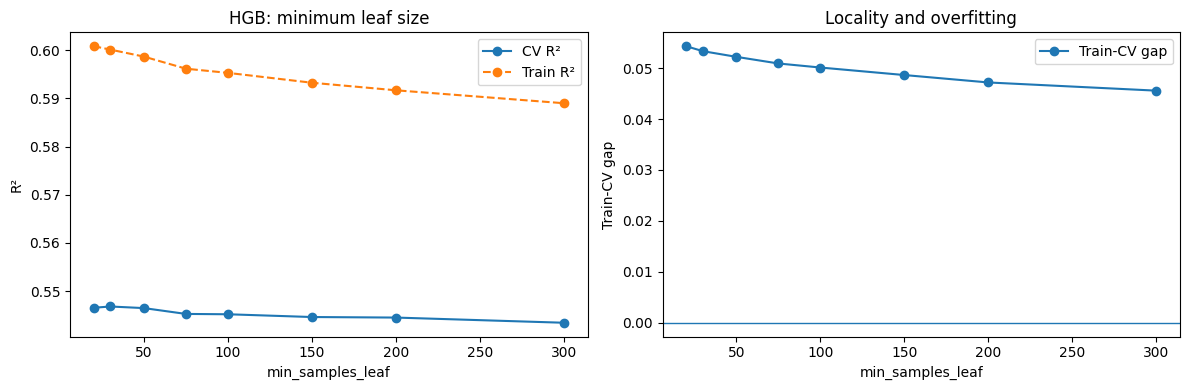

In [34]:
if not min_leaf.empty and {"min_samples_leaf", "cv_r2"}.issubset(min_leaf.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    g = min_leaf.sort_values("min_samples_leaf")

    axes[0].plot(g["min_samples_leaf"], g["cv_r2"], marker="o", label="CV R²")
    if "train_r2" in g.columns:
        axes[0].plot(g["min_samples_leaf"], g["train_r2"], marker="o", linestyle="--", label="Train R²")
    axes[0].set_xlabel("min_samples_leaf")
    axes[0].set_ylabel("R²")
    axes[0].set_title("HGB: minimum leaf size")
    axes[0].legend()

    if "overfit_gap" in g.columns:
        axes[1].plot(g["min_samples_leaf"], g["overfit_gap"], marker="o", label="Train-CV gap")
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("min_samples_leaf")
    axes[1].set_ylabel("Train-CV gap")
    axes[1].set_title("Locality and overfitting")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F4_hgb_min_leaf_cv_gap.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Min-samples-leaf sweep data not available.")

## 09. L2 regularization sweep

In [35]:
l2_sweep = hgb_cv_all.query("experiment == 'hgb_l2'").copy()

T6_cols = [
    "experiment",
    "l2_regularization",
    "cv_r2",
    "cv_r2_std",
    "train_r2",
    "overfit_gap",
    "mean_fit_time",
    "learning_rate",
    "max_iter",
    "max_leaf_nodes",
    "min_samples_leaf",
]
T6_cols = [c for c in T6_cols if c in l2_sweep.columns]

T6_hgb_l2_tradeoff = (
    l2_sweep[T6_cols]
    .sort_values("l2_regularization")
    .reset_index(drop=True)
    if not l2_sweep.empty and "l2_regularization" in l2_sweep.columns else pd.DataFrame(columns=T6_cols)
)

T6_hgb_l2_tradeoff.to_csv(TABLE_DIR / "T6_hgb_l2_tradeoff.csv", index=False)
T6_hgb_l2_tradeoff.round(6)

,experiment,l2_regularization,cv_r2,cv_r2_std,train_r2,overfit_gap,mean_fit_time,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf
0,hgb_l2,0.000,0.547758,0.012804,0.628227,0.080468,7.183632,0.05,200,63,100
1,hgb_l2,0.001,0.547759,0.012805,0.628226,0.080467,7.266572,0.05,200,63,100
2,hgb_l2,0.003,0.547687,0.012780,0.628262,0.080574,7.877397,0.05,200,63,100
3,hgb_l2,0.010,0.548231,0.011639,0.628252,0.080021,6.891683,0.05,200,63,100
4,hgb_l2,0.030,0.548063,0.012267,0.628099,0.080037,7.545243,0.05,200,63,100
5,hgb_l2,0.100,0.548071,0.011870,0.627964,0.079893,7.266445,0.05,200,63,100
6,hgb_l2,0.300,0.547414,0.012774,0.628166,0.080753,8.575627,0.05,200,63,100
7,hgb_l2,1.000,0.547640,0.012707,0.628107,0.080467,7.126878,0.05,200,63,100


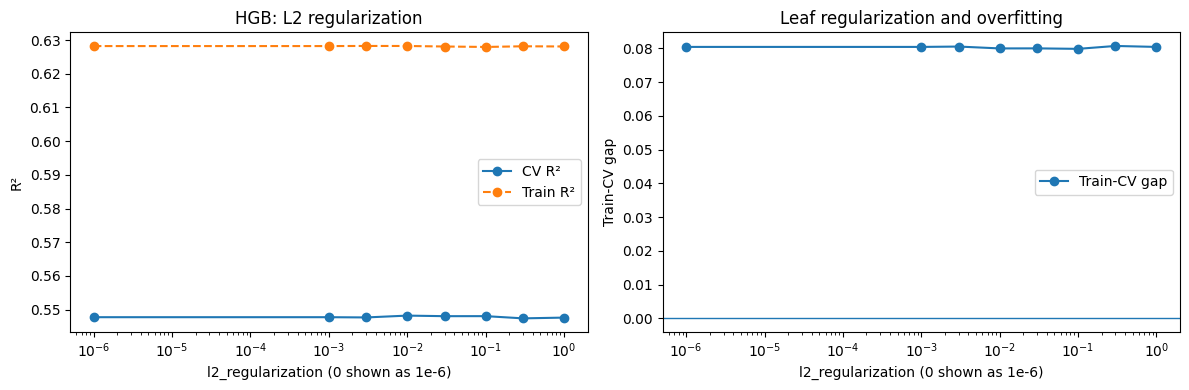

In [36]:
if not l2_sweep.empty and {"l2_regularization", "cv_r2"}.issubset(l2_sweep.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    g = l2_sweep.sort_values("l2_regularization").copy()
    # Add small offset for log plotting if l2 includes zero.
    g["l2_plot"] = g["l2_regularization"].where(g["l2_regularization"] > 0, 1e-6)

    axes[0].plot(g["l2_plot"], g["cv_r2"], marker="o", label="CV R²")
    if "train_r2" in g.columns:
        axes[0].plot(g["l2_plot"], g["train_r2"], marker="o", linestyle="--", label="Train R²")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("l2_regularization (0 shown as 1e-6)")
    axes[0].set_ylabel("R²")
    axes[0].set_title("HGB: L2 regularization")
    axes[0].legend()

    if "overfit_gap" in g.columns:
        axes[1].plot(g["l2_plot"], g["overfit_gap"], marker="o", label="Train-CV gap")
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("l2_regularization (0 shown as 1e-6)")
    axes[1].set_ylabel("Train-CV gap")
    axes[1].set_title("Leaf regularization and overfitting")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F5_hgb_l2_regularization_cv_gap.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("L2 sweep data not available.")

## 10. Error by income decile

decile_col: income_decile
mae_col: mae
resid_col: residual_mean


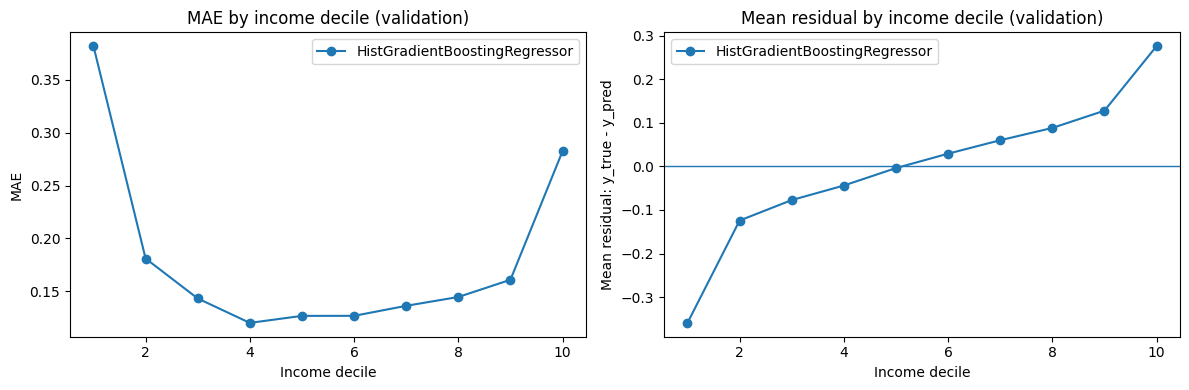

In [37]:
# Prefer quick benchmark if available, otherwise baseline HGB.
decile_source = None
if bundles.get("hgb_quick_benchmark") and not bundles["hgb_quick_benchmark"]["error_by_decile"].empty:
    decile_source = bundles["hgb_quick_benchmark"]["error_by_decile"].copy()
elif baseline_bundle and not baseline_bundle["error_by_decile"].empty:
    decile_source = baseline_bundle["error_by_decile"].copy()
else:
    decile_source = pd.DataFrame()

if not decile_source.empty:
    decile_col = first_existing(decile_source.columns, ["income_decile", "decile", "y_true_decile"])
    mae_col = first_existing(decile_source.columns, ["mae", "abs_error_mean", "mean_abs_error", "mae_mean"])
    resid_col = first_existing(decile_source.columns, ["residual_mean", "mean_residual", "residual"])

    print("decile_col:", decile_col)
    print("mae_col:", mae_col)
    print("resid_col:", resid_col)

    split_name = "validation"
    plot_df = decile_source.query("split == @split_name").copy()

    # Keep HGB and optionally linear reference if present.
    if "model" in plot_df.columns:
        keep_models = plot_df["model"].astype(str).str.contains("HistGradientBoosting|LinearRegression|Ridge|Lasso", regex=True)
        plot_df = plot_df[keep_models].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for model_name, g in plot_df.groupby("model"):
        g = g.sort_values(decile_col)
        if mae_col is not None:
            axes[0].plot(g[decile_col], g[mae_col], marker="o", label=model_name)
        if resid_col is not None:
            axes[1].plot(g[decile_col], g[resid_col], marker="o", label=model_name)

    axes[0].set_xlabel("Income decile")
    axes[0].set_ylabel("MAE")
    axes[0].set_title(f"MAE by income decile ({split_name})")

    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("Income decile")
    axes[1].set_ylabel("Mean residual: y_true - y_pred")
    axes[1].set_title(f"Mean residual by income decile ({split_name})")

    axes[0].legend()
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F6_hgb_decile_errors.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No decile error artifact found.")

## 11. Prediction compression and distribution

In [38]:
distribution_frames = []

for name, b in bundles.items():
    dist = b["prediction_distribution"].copy()
    if dist.empty:
        continue

    if "std_ratio" not in dist.columns and {"y_pred_std", "y_true_std"}.issubset(dist.columns):
        dist["std_ratio"] = dist["y_pred_std"] / dist["y_true_std"]

    dist["source_experiment"] = name
    distribution_frames.append(dist)

distribution_all = pd.concat(distribution_frames, ignore_index=True) if distribution_frames else pd.DataFrame()

T7_cols = [
    "source_experiment",
    "experiment",
    "model",
    "split",
    "row_count",
    "y_true_std",
    "y_pred_std",
    "std_ratio",
    "y_true_min",
    "y_pred_min",
    "y_true_max",
    "y_pred_max",
]
T7_cols = [c for c in T7_cols if c in distribution_all.columns]

T7_hgb_distribution_error_summary = distribution_all[T7_cols].copy() if not distribution_all.empty else pd.DataFrame(columns=T7_cols)
T7_hgb_distribution_error_summary.to_csv(TABLE_DIR / "T7_hgb_distribution_error_summary.csv", index=False)

T7_hgb_distribution_error_summary.round(6).head(30)

,source_experiment,experiment,model,split,row_count,y_true_std,y_pred_std,std_ratio,y_true_min,y_pred_min,y_true_max,y_pred_max
0,baseline,baseline,HistGradientBoostingRegressor,test,71358,0.378055,0.288176,0.762258,2.004321,2.239667,5.808967,4.977870
1,baseline,baseline,HistGradientBoostingRegressor,validation,35679,0.378025,0.286982,0.759160,2.004321,2.355519,5.254681,4.553628
2,baseline,baseline,Lasso,test,71358,0.378055,0.229069,0.605914,2.004321,2.680525,5.808967,4.352893
3,baseline,baseline,Lasso,validation,35679,0.378025,0.228458,0.604347,2.004321,2.676439,5.254681,4.308288
4,baseline,baseline,LinearRegression,test,71358,0.378055,0.244007,0.645426,2.004321,2.735795,5.808967,4.531485
5,baseline,baseline,LinearRegression,validation,35679,0.378025,0.243085,0.643039,2.004321,2.679829,5.254681,4.556068
6,baseline,baseline,MLPRegressor,test,71358,0.378055,0.290653,0.768811,2.004321,2.247873,5.808967,4.716121
7,baseline,baseline,MLPRegressor,validation,35679,0.378025,0.289137,0.764861,2.004321,2.286648,5.254681,4.561645
8,baseline,baseline,Ridge,test,71358,0.378055,0.243971,0.645332,2.004321,2.736776,5.808967,4.531356
9,baseline,baseline,Ridge,validation,35679,0.378025,0.243051,0.642950,2.004321,2.682905,5.254681,4.555975


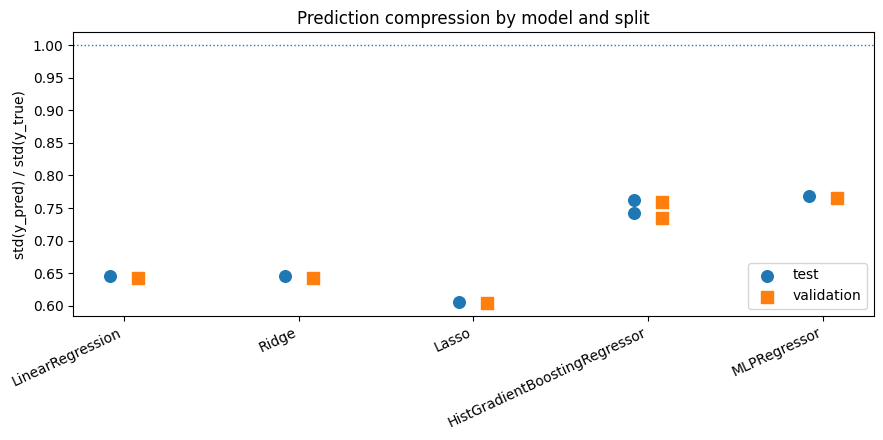

In [39]:
if not T7_hgb_distribution_error_summary.empty and "std_ratio" in T7_hgb_distribution_error_summary.columns:
    # Prefer one row per model from baseline, and quick benchmark if present.
    plot_df = T7_hgb_distribution_error_summary.query("split in ['test', 'validation']").copy()

    # Keep manageable: baseline plus quick benchmark.
    if "source_experiment" in plot_df.columns:
        keep_sources = ["baseline", "hgb_quick_benchmark"]
        plot_df = plot_df[plot_df["source_experiment"].isin(keep_sources)].copy()

    # Prefer model order.
    preferred_order = [
        "LinearRegression",
        "Ridge",
        "Lasso",
        "HistGradientBoostingRegressor",
        "MLP",
    ]
    model_order = [m for m in preferred_order if m in plot_df["model"].unique()]
    model_order += [m for m in plot_df["model"].unique() if m not in model_order]
    x_positions = {m: i for i, m in enumerate(model_order)}

    split_offsets = {"test": -0.08, "validation": 0.08}
    split_markers = {"test": "o", "validation": "s"}

    fig, ax = plt.subplots(figsize=(9, 4.5))

    for split, g in plot_df.groupby("split"):
        xs = [x_positions[m] + split_offsets.get(split, 0) for m in g["model"]]
        ax.scatter(xs, g["std_ratio"], s=70, marker=split_markers.get(split, "o"), label=split)

    ax.axhline(1, linewidth=1, linestyle=":")
    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order, rotation=25, ha="right")
    ax.set_ylabel("std(y_pred) / std(y_true)")
    ax.set_title("Prediction compression by model and split")
    ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F7_hgb_prediction_compression.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No distribution summary available.")

## 12. Observed vs predicted

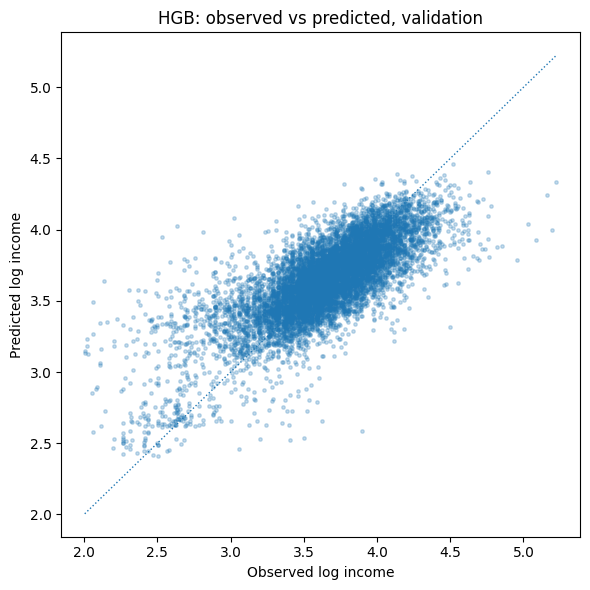

In [40]:
# Prefer HGB quick benchmark predictions, otherwise baseline predictions.
prediction_source = None

if bundles.get("hgb_quick_benchmark") and not bundles["hgb_quick_benchmark"]["predictions"].empty:
    prediction_source = bundles["hgb_quick_benchmark"]["predictions"].copy()
elif baseline_bundle and not baseline_bundle["predictions"].empty:
    prediction_source = baseline_bundle["predictions"].copy()
else:
    prediction_source = pd.DataFrame()

if not prediction_source.empty:
    pred = prediction_source.query("split == 'validation'").copy()
    if "model" in pred.columns:
        hgb_pred = pred[pred["model"].astype(str).str.contains("HistGradientBoosting", regex=True)].copy()
        if hgb_pred.empty:
            hgb_pred = pred.copy()
    else:
        hgb_pred = pred.copy()

    # Deterministic sample for plotting if large.
    if len(hgb_pred) > 15000:
        hgb_pred = hgb_pred.sample(15000, random_state=42)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(hgb_pred["y_true"], hgb_pred["y_pred"], s=6, alpha=0.25)

    lo = min(hgb_pred["y_true"].min(), hgb_pred["y_pred"].min())
    hi = max(hgb_pred["y_true"].max(), hgb_pred["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], linewidth=1, linestyle=":")

    ax.set_xlabel("Observed log income")
    ax.set_ylabel("Predicted log income")
    ax.set_title("HGB: observed vs predicted, validation")

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F8_hgb_observed_vs_predicted.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No prediction artifact available for observed-vs-predicted plot.")

## 13. Selected config manifest and findings

In [41]:
# T8: selected config manifest from best available HGB config rows.
selected_rows = []

if not hgb_cv_all.empty:
    for experiment, g in hgb_cv_all.dropna(subset=["cv_r2"]).groupby("experiment"):
        best = g.sort_values("cv_r2", ascending=False).iloc[0].to_dict()
        selected_rows.append(best)

T8_hgb_selected_config_manifest = pd.DataFrame(selected_rows)

T8_cols = [
    "experiment",
    "cv_r2",
    "cv_r2_std",
    "train_r2",
    "overfit_gap",
    "learning_rate",
    "max_iter",
    "max_leaf_nodes",
    "min_samples_leaf",
    "l2_regularization",
    "mean_fit_time",
    "rank_test_score",
]
T8_cols = [c for c in T8_cols if c in T8_hgb_selected_config_manifest.columns]
T8_hgb_selected_config_manifest = T8_hgb_selected_config_manifest[T8_cols] if not T8_hgb_selected_config_manifest.empty else pd.DataFrame(columns=T8_cols)

T8_hgb_selected_config_manifest.to_csv(TABLE_DIR / "T8_hgb_selected_config_manifest.csv", index=False)
T8_hgb_selected_config_manifest.round(6)

,experiment,cv_r2,cv_r2_std,train_r2,overfit_gap,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,mean_fit_time,rank_test_score
0,baseline,0.562229,0.017551,NaN,NaN,0.050,200,400,15,0.00,52.173794,1
1,hgb_l2,0.548231,0.011639,0.628252,0.080021,0.050,200,63,100,0.01,6.891683,1
2,hgb_leaf_capacity,0.548996,0.011108,0.652949,0.103952,0.050,200,95,100,0.00,8.893732,1
3,hgb_lr_iter,0.547219,0.013558,0.617381,0.070162,0.030,600,31,100,0.00,14.329030,1
4,hgb_min_leaf,0.546811,0.012973,0.600133,0.053322,0.050,200,31,30,0.00,4.950497,1
5,hgb_quick_benchmark,0.544790,0.013599,0.607675,0.062885,0.075,200,31,100,0.00,3.765610,1


In [42]:
findings = {
    "notebook": "03_hgb_capacity_and_distribution",
    "available_runs": {
        name: str(path) if path is not None else None
        for name, path in run_dirs.items()
    },
    "final_tables": sorted(p.name for p in TABLE_DIR.glob("T*.csv")),
    "final_figures": sorted(p.name for p in FIG_DIR.glob("F*.png")),
    "scientific_roles": [
        "HGB is treated as a nonlinear diagnostic, not merely as a leaderboard winner.",
        "The benchmark comparison tests whether nonlinear structure raises the predictive frontier over the linear family.",
        "The lr-iter sweep studies sequential boosting dynamics.",
        "The leaf-capacity sweep studies interaction capacity per tree.",
        "The min-leaf sweep studies locality and smoothness of terminal leaves.",
        "The l2 sweep studies whether leaf-value regularization improves generalization.",
        "Decile and compression diagnostics test whether average gains translate into better distributional behavior.",
    ],
    "interpretive_cautions": [
        "If a sweep run is missing, the corresponding table/figure will be empty or skipped.",
        "CV results depend on the fold design in each YAML config.",
        "Distributional interpretation should use validation/test predictions, not training fit.",
        "HGB improves flexibility but may still compress tails.",
    ],
    "backend_gaps_to_consider": [
        "Ensure all HGB runs emit distribution_compression_summary.csv.",
        "Ensure all HGB sweeps emit hgb_top_configs.csv and hgb_overfit_gap_by_config.csv.",
        "Consider permutation importance or partial dependence later, but do not mix it into the first capacity notebook unless needed.",
    ],
}

with open(OUTPUT_DIR / "findings.json", "w") as f:
    json.dump(findings, f, indent=2)

print("Saved final tables to:", TABLE_DIR)
print("Saved final figures to:", FIG_DIR)
print(json.dumps(findings, indent=2))

Saved final tables to: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/hgb_capacity_and_distribution/tables
Saved final figures to: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/hgb_capacity_and_distribution/figures
{
  "notebook": "03_hgb_capacity_and_distribution",
  "available_runs": {
    "baseline": "/home/matias/repos/income-modeling-eph/reports/runs/baseline_income_prediction_v1_20260608T100650Z",
    "hgb_sweep": "/home/matias/repos/income-modeling-eph/reports/runs/hgb_sweep_v1_20260517T092712Z",
    "hgb_lr_iter": "/home/matias/repos/income-modeling-eph/reports/runs/hgb_lr_iter_sweep_v1_20260609T063641Z",
    "hgb_leaf_capacity": "/home/matias/repos/income-modeling-eph/reports/runs/hgb_leaf_capacity_sweep_v1_20260609T063012Z",
    "hgb_min_leaf": "/home/matias/repos/income-modeling-eph/reports/runs/hgb_min_leaf_sweep_v1_20260609T063344Z",
    "hgb_l2": "/home/matias/repos/income-modeling-eph/reports/runs/hgb_l2_sweep_v1_20260609T064712Z",
    